In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [47]:
df = pd.read_csv('../AICE/data/california.csv')
df = df.drop(columns='total_bedrooms')
df.head()

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   population          20640 non-null  float64
 5   households          20640 non-null  float64
 6   median_income       20640 non-null  float64
 7   median_house_value  20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.4+ MB


In [49]:
rng = np.random.default_rng(42)
missing_count = 20

df_missing = df.copy()

rows = rng.integers(0, df_missing.shape[0], size=missing_count)
cols = rng.integers(0, df_missing.shape[1], size=missing_count)

print(rows)
print(cols)

[ 1842 15974 13510  9058  8937 17721  1773 14393  4158  1943 10866 20136
 15185 15709 14808 16224 10592  2644 17332  9295]
[4 3 1 8 7 5 3 7 4 3 4 2 0 4 7 0 7 7 2 5]


In [50]:
for i in range(missing_count):
    df_missing.iloc[rows[i], cols[i]] = np.nan

In [51]:
df_missing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20638 non-null  float64
 1   latitude            20639 non-null  float64
 2   housing_median_age  20638 non-null  float64
 3   total_rooms         20637 non-null  float64
 4   population          20636 non-null  float64
 5   households          20638 non-null  float64
 6   median_income       20640 non-null  float64
 7   median_house_value  20635 non-null  float64
 8   ocean_proximity     20639 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.4+ MB


In [52]:
df_missing.isna().sum()

longitude             2
latitude              1
housing_median_age    2
total_rooms           3
population            4
households            2
median_income         0
median_house_value    5
ocean_proximity       1
dtype: int64

In [53]:
df_missing.isna().sum().sum()

np.int64(20)

In [55]:
cond = df_missing.isna().any(axis=1)
df[cond].head(20)

,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value,ocean_proximity
1773,-122.34,37.94,47.0,2313.0,947.0,430.0,3.9420,143300.0,NEAR BAY
1842,-122.29,37.91,40.0,2085.0,796.0,339.0,5.5357,273700.0,NEAR BAY
1943,-120.91,38.62,12.0,4545.0,2033.0,718.0,4.1843,207600.0,INLAND
2644,-124.14,40.58,25.0,1899.0,891.0,355.0,2.6987,92500.0,<1H OCEAN
4158,-118.19,34.11,40.0,1266.0,1032.0,315.0,2.1667,150000.0,<1H OCEAN
8937,-118.47,34.01,44.0,2175.0,1019.0,448.0,4.7930,470800.0,<1H OCEAN
9058,-118.14,34.69,35.0,2118.0,1108.0,360.0,3.4327,100300.0,INLAND
9295,-122.49,38.00,26.0,48.0,19.0,8.0,7.7197,400000.0,NEAR BAY
10592,-117.78,33.69,16.0,3400.0,1575.0,488.0,6.0961,295500.0,<1H OCEAN
10866,-117.88,33.70,18.0,2135.0,1464.0,405.0,5.4836,225800.0,<1H OCEAN


In [ ]:
df_missing_screen = df_missing.dropna()
df_missing_screen.isna().any()

np.False_

In [60]:
num_only = df_missing.select_dtypes(include='number').columns
num_only

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'population', 'households', 'median_income', 'median_house_value'],
      dtype='object')

In [66]:
print(df_missing[num_only].quantile(0.25))
df_missing.describe()

longitude               -121.8000
latitude                  33.9300
housing_median_age        18.0000
total_rooms             1448.0000
population               787.0000
households               280.0000
median_income              2.5634
median_house_value    119600.0000
Name: 0.25, dtype: float64


,longitude,latitude,housing_median_age,total_rooms,population,households,median_income,median_house_value
count,20638.000000,20639.000000,20638.000000,20637.000000,20636.000000,20638.000000,20640.000000,20635.000000
mean,-119.569739,35.631934,28.639258,2635.757378,1425.562076,499.564202,3.870671,206838.083887
std,2.003518,2.135979,12.586142,2181.708228,1132.547154,382.332954,1.899822,115387.804110
min,-124.350000,32.540000,1.000000,2.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1448.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,1725.000000,605.000000,4.743250,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,35682.000000,6082.000000,15.000100,500001.000000


In [67]:
#df_missing_screen = df_missing[num_only].fillna(df_missing[num_only].quantile(0.25))
df_missing_screen = df_missing[num_only].fillna(df_missing[num_only].mean())
df_missing_screen.isna().any()

longitude             False
latitude              False
housing_median_age    False
total_rooms           False
population            False
households            False
median_income         False
median_house_value    False
dtype: bool

In [68]:
df_missing_screen = df_missing.ffill()
df_missing_screen.isna().any()

longitude             False
latitude              False
housing_median_age    False
total_rooms           False
population            False
households            False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool

In [69]:
df_missing_screen = df_missing.bfill()
df_missing_screen.isna().any()

longitude             False
latitude              False
housing_median_age    False
total_rooms           False
population            False
households            False
median_income         False
median_house_value    False
ocean_proximity       False
dtype: bool

<Axes: >

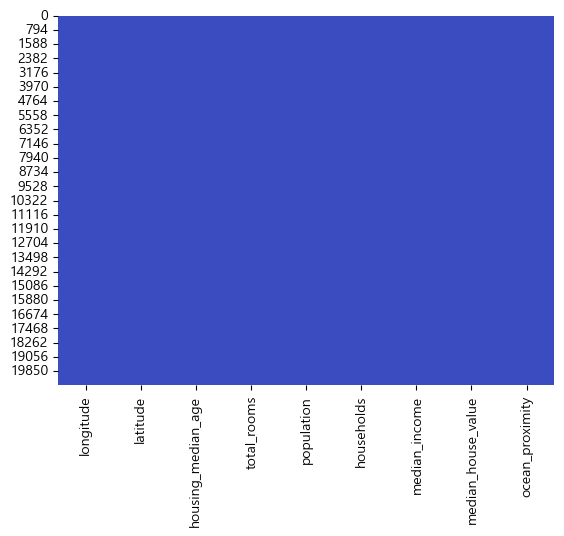

In [72]:
sns.heatmap(df_missing.isna(), cbar=False, cmap='coolwarm')